In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt

import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
from utils import*

In [10]:
# Carregamento de dados

lista_arquivos = os.listdir(str(BASE_DIR) + r"\data\input")

for file in lista_arquivos:


_IncompleteInputError: incomplete input (4281628991.py, line 5)

In [11]:
# Dados

dados_brutos, metadados, variaveis = dados(r"data\input\dados_brutos.xlsx")

dados_limpos, metadados, variaveis = dados(r"data\input\dados_limpos.xlsx")

imput_mean_limpos, metadados, variaveis = dados(r"data\input\imput_mean_limpos.xlsx")

imput_median_limpos, metadados, variaveis = dados(r"data\input\imput_median_limpos.xlsx")

imput_knn_limpos, metadados, variaveis = dados(r"data\input\imput_knn_limpos.xlsx")

imput_mean_zscore, metadados, variaveis = dados(r"data\input\imput_mean_zscore.xlsx")

imput_median_zscore, metadados, variaveis = dados(r"data\input\imput_median_zscore.xlsx")

imput_knn_zscore, metadados, variaveis = dados(r"data\input\imput_knn_zscore.xlsx")

imput_mean_iqr, metadados, variaveis = dados(r"data\input\imput_mean_iqr.xlsx")

imput_median_iqr, metadados, variaveis = dados(r"data\input\imput_median_iqr.xlsx")

imput_knn_iqr, metadados, variaveis = dados(r"data\input\imput_knn_iqr.xlsx")

In [32]:
# type(dados_brutos)

print(dados_limpos['Data'].dtype, end='')
print(dados_limpos['data_normalizada'].dtype)

datetime64[ns]datetime64[ns]


# K-Means - Clustering

Os dados normalizados serão preparados selecionando variáveis relevantes (ex.: pH, condutividade elétrica, nitrato). 

O algoritmo será aplicado para agrupar os dados por similaridade, testando n_clusters de 2 a 10, definido pelo método do cotovelo (Kaufman; Russeeuw, 1990). 

O objetivo é identificar padrões espaciais ou temporais (ex.: regiões com alta turbidez) para manejo hídrico. 

In [ ]:
# Primeira tentativa

from sklearn.cluster import KMeans

# Salvar cópia das colunas das variáveis numa variável
X = dados_limpos[variaveis].copy()

# Eliminar células vaziass
Xnonan = X.dropna()

# kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto").fit(Xnonan)
print(X)

       COR  TURB.   pH  ALC.   AC.  O.C.  O.D.    Cl  DUR.     Fe    Mn  \
0    200.0   64.0  7.0  29.0   3.0   6.3   2.0  16.0  36.0   3.23  0.09   
1    432.0  131.0  7.2  34.0   5.0   6.8   3.5  23.0  47.0   6.26  0.17   
2    690.0  241.0  7.4  38.0   8.0   7.5   4.8  33.0  66.0  11.20  0.32   
3    393.0   72.0  6.5  29.0   6.0   5.9   2.8  20.0  30.0   6.82  0.08   
4    868.0  238.0  7.1  31.0   7.0   7.2   4.1  21.0  33.0   9.55  0.12   
..     ...    ...  ...   ...   ...   ...   ...   ...   ...    ...   ...   
571  217.0  134.0  7.5  48.0   9.0   9.7   4.2  39.0  63.0   1.57  0.11   
572  805.0  746.0  7.8  60.0  18.0  17.6   6.0  45.0  96.0   2.80  0.19   
573    NaN    NaN  NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN   NaN   
574    NaN    NaN  NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN   NaN   
575    NaN    NaN  NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN   NaN   

     Cond.  Cianobacteria     C.F.  Clorofila     F  
0    131.0         6600.0  23000.0       2.23

In [12]:
# Setup

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Salvar cópia das colunas das variáveis numa variável
X = dados_limpos[variaveis].copy()

# Eliminar células vaziass
X_nonan = X.dropna(axis=0, how='any')
# Salvar o Index do DataFrame sem células vazias numa variável
idx_nonan = X_nonan.index

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_nonan)

pca = PCA(n_components=0.95, random_state=0)
X_pca = pca.fit_transform(X_scaled)

In [18]:
# Teste

kmeans = KMeans(n_clusters=2, random_state=0)
cluster_labels = kmeans.fit_predict(X_nonan)
distancias = np.linalg.norm(X_nonan - kmeans.cluster_centers_[cluster_labels], axis=1)

kmeans.labels_

# distancias

array([0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
# Teste

kmeans = KMeans(n_clusters=2, random_state=0)
cluster_labels = kmeans.fit_predict(X_pca)
distancias = np.linalg.norm(X_pca - kmeans.cluster_centers_[cluster_labels], axis=1)

kmeans.labels_

# distancias

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1,

In [ ]:
n_clusters_list = [2, 3, 4]

fig, axs = plt.subplots(
    1,
    len(n_clusters_list),
    figsize=(20, 10)
)

axs = axs.T

for i, n_clusters in enumerate(n_clusters_list):
    kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init="auto")
    kmeans.fit(X_pca)
    centers = kmeans.cluster_centers_

    axs[i].scatter(X_pca[:, 0], X_pca[:, 1], s=10, c=kmeans.labels_)
    axs[i].scatter(centers[:, 0], centers[:, 1], c="r", s=20)

    axs[i].set_title(f"{kmeans} : {n_clusters} clusters")

for ax in axs.flat:
    ax.label_outer()
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()

plt.show()

In [19]:
X_nonan

,COR,TURB.,pH,ALC.,AC.,O.C.,O.D.,Cl,DUR.,Fe,Mn,Cond.,Cianobacteria,C.F.,Clorofila,F
0,200.0,64.0,7.0,29.0,3.0,6.3,2.0,16.0,36.0,3.23,0.09,131.0,6600.0,23000.0,2.23,0.12
1,432.0,131.0,7.2,34.0,5.0,6.8,3.5,23.0,47.0,6.26,0.17,145.0,6850.0,23000.0,11.35,0.16
2,690.0,241.0,7.4,38.0,8.0,7.5,4.8,33.0,66.0,11.20,0.32,156.0,7100.0,23000.0,22.32,0.19
3,393.0,72.0,6.5,29.0,6.0,5.9,2.8,20.0,30.0,6.82,0.08,128.0,1100.0,30000.0,6.69,0.12
4,868.0,238.0,7.1,31.0,7.0,7.2,4.1,21.0,33.0,9.55,0.12,133.0,2100.0,30000.0,7.81,0.16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
559,52.0,11.0,7.5,89.0,7.0,11.2,3.5,52.0,75.0,1.01,0.13,474.0,12701.0,4100.0,54.68,0.33
560,180.0,48.0,7.9,100.0,11.0,46.2,5.8,60.0,124.0,1.40,0.36,537.0,16770.0,4100.0,54.68,0.42
561,36.0,5.0,7.5,68.0,7.0,4.6,2.0,50.0,12.0,0.51,0.05,398.0,3466.0,2200.0,136.90,0.27
562,65.0,9.0,7.7,87.0,31.0,9.1,4.5,57.0,61.0,0.60,0.07,526.0,8866.0,2200.0,136.90,0.35


C:\Users\Wary\AppData\Local\Temp\ipykernel_26276\1597893924.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 1])


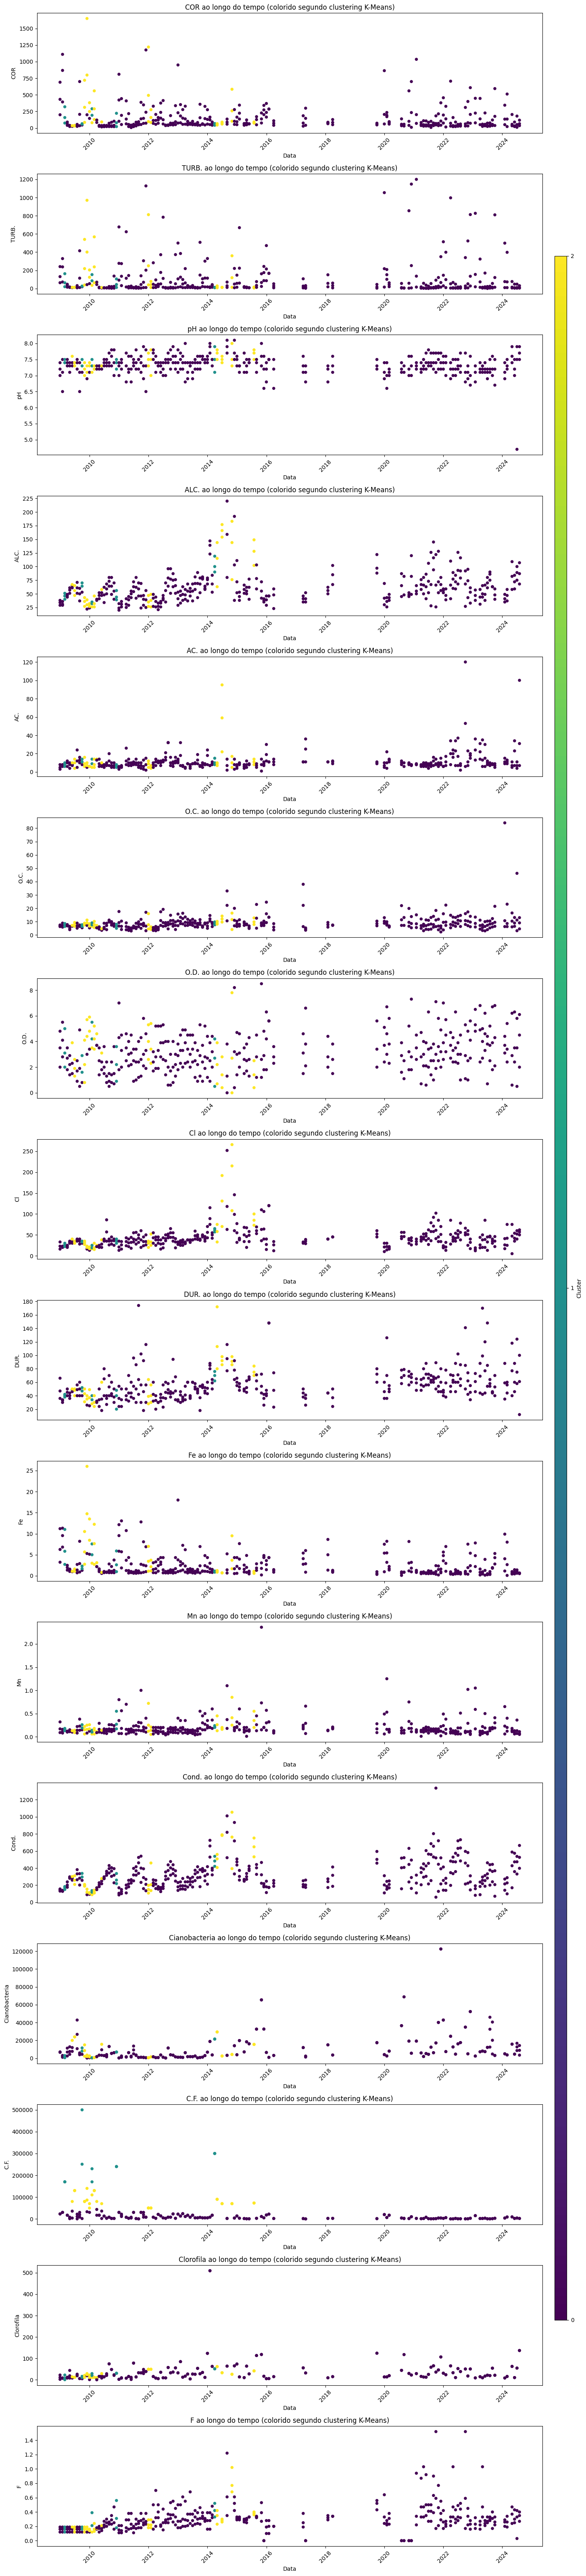

In [38]:
# Teste

n_clusters = 3  # De acordo com os testes anteriores, 3 parece ser o melhor número de clusters

kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init="auto")
kmeans.fit(X_nonan)  # Talvez trocar X_nonan para X_pca
labels = kmeans.labels_

# Extrai datas que correspondem com as linhas de idx_nonan (algumas são removidas devido às células vazias)
dates = dados_limpos.loc[idx_nonan, 'data_normalizada']

# Subplots individuais para as variáveis
fig, axs = plt.subplots(len(variaveis), 1, figsize=(15, 4*len(variaveis)))

if len(variaveis) == 1:
    axs = [axs]

for i, var in enumerate(variaveis):
    scatter = axs[i].scatter(dates, X_nonan[var], c=labels, cmap='viridis', s=20)
    axs[i].set_ylabel(var)
    axs[i].set_xlabel('Data')
    axs[i].set_title(f'{var} ao longo do tempo (colorido segundo clustering K-Means)')
    axs[i].tick_params(axis='x', rotation=45)

cbar_ax = fig.add_axes([0.92, 0.1, 0.02, 0.8])
cbar = fig.colorbar(scatter, cax=cbar_ax, label='Cluster')
cbar.set_ticks(range(n_clusters))

plt.tight_layout(rect=[0, 0, 0.91, 1])
plt.show()

C:\Users\Wary\AppData\Local\Temp\ipykernel_26276\991615139.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 1])


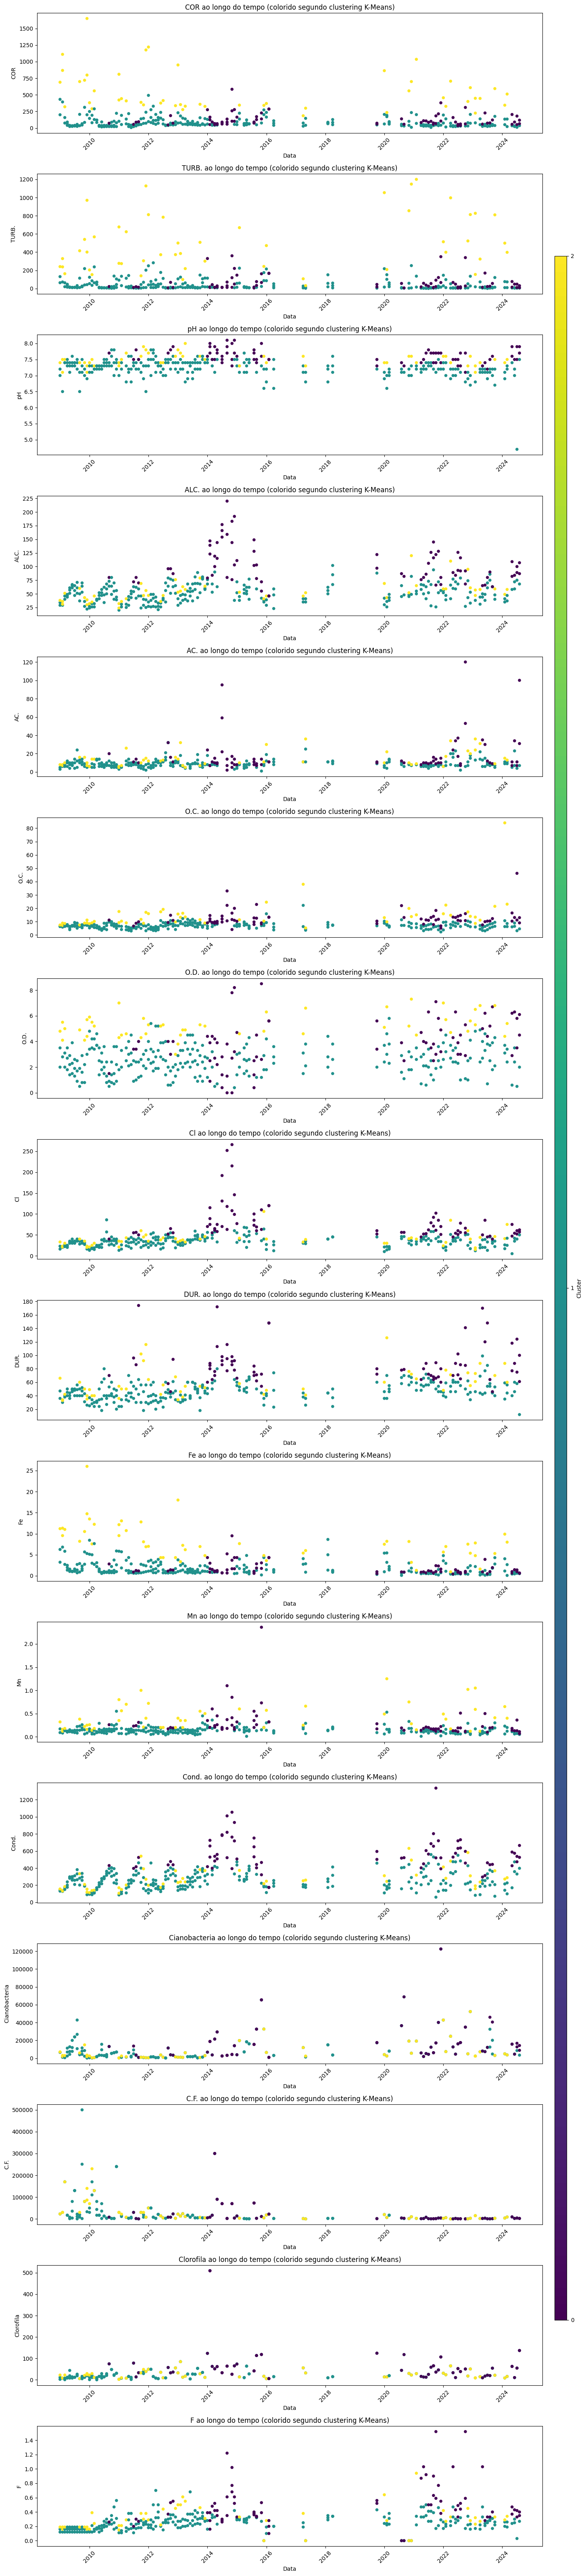

In [39]:
n_clusters = 3  # De acordo com os testes anteriores, 3 parece ser o melhor número de clusters

kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init="auto")
kmeans.fit(X_pca)  # Alteração que eu tinha mencionado no último Jupyter Notebook
labels = kmeans.labels_

# Extrai datas que correspondem com as linhas de idx_nonan (algumas são removidas devido às células vazias)
dates = dados_limpos.loc[idx_nonan, 'data_normalizada']

# Subplots individuais para as variáveis
fig, axs = plt.subplots(len(variaveis), 1, figsize=(15, 4*len(variaveis)))

if len(variaveis) == 1:
    axs = [axs]

for i, var in enumerate(variaveis):
    scatter = axs[i].scatter(dates, X_nonan[var], c=labels, cmap='viridis', s=20)
    axs[i].set_ylabel(var)
    axs[i].set_xlabel('Data')
    axs[i].set_title(f'{var} ao longo do tempo (colorido segundo clustering K-Means)')
    axs[i].tick_params(axis='x', rotation=45)

cbar_ax = fig.add_axes([0.92, 0.1, 0.02, 0.8])
cbar = fig.colorbar(scatter, cax=cbar_ax, label='Cluster')
cbar.set_ticks(range(n_clusters))

plt.tight_layout(rect=[0, 0, 0.91, 1])
plt.show()

![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

# Random Forest - Classificação

Os dados serão divididos em treinamento (80%) e teste (20%). 

O modelo será treinado com n_estimators=100 e profundidade limitada para evitar overfitting, classificando a qualidade da água (ex.: adequada/inadequada, conforme Resolução 
CONAMA 357/2005, Brasil, 2012).  

In [ ]:
from sklearn.ensemble import RandomForestClassifier # Documentação: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
from sklearn.datasets import make_classification    # Lendo a documentação (https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_classification.html) 
                                                    # desse método, acho que ele só serve para gerar um problema aleatório de classificação.

# Estabelece as regras para o funcionamento do Classificador
clf = RandomForestClassifier(n_estimators=100,  # n_estimators=100 é default, mas como está nas instruções do relatório decidi evidenciar.
                             
                             bootstrap=True,    # bootstrap=True também é default, mas acho que é importante ele ser True para determinar a divisão de dados de treinamento e teste. Não sei ao certo.

                             max_samples=0.8,   # Pelo meu entendimento, isso deveria ser a quantidade de dados utilizados no treinamento, portanto, 80% do número de linhas (0.8 * shape[0]).
                                                                    # InvalidParameterError: The 'max_samples' parameter of RandomForestClassifier must be None, a float in the range (0.0, 1.0] or an int in the range [1, inf). Got 460.8 instead.
                                                                    # Acho que o certo então é só colocar 0.8 --> Funcionou

                            #  n_classes=2      # Acho que como nós queremos classificar a qualidade da água em "adequada" ou "inadequada", n_classes=2. 
                                                # Esquece: RandomForestClassifier.__init__() got an unexpected keyword argument 'n_classes'  
                                                                                     
                            #  n_features=      # Não entendo, mas parece importante
                             ) 

# Faz o fit do classificador, necessário para o funcionamento de estimators (NotFittedError: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.)

clf.fit(dados_limpos)   # Preciso de um argumento X e um y, mas não sei ao certo o que seria qual.

TypeError: BaseForest.fit() missing 1 required positional argument: 'y'

In [9]:
# clf.apply(dados_limpos)

clf.decision_path(dados_limpos)

NotFittedError: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [7]:
dados_limpos.shape[0]*.8

460.8

![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

# Isolation Forest - Detecção de Anomalias

Após clustering, os dados serão processados para detectar anomalias isoladas, ajustando contamination (0,05–0,1) com base na análise exploratória. 

O algoritmo identificará picos de contaminação (ex.: fósforo elevado), focando em eventos críticos. 

In [15]:
from sklearn.ensemble import IsolationForest

X = dados_limpos[variaveis].copy()

isf = IsolationForest(contamination=0.05).fit(X)

isf.predict(X)

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1, -1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1, -1, -1, -1,
        1,  1, -1,  1, -1, -1,  1,  1, -1,  1,  1, -1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1